<a href="https://colab.research.google.com/github/Olya-Shulga/Univercity/blob/main/neural_networks/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%9610_%D0%A1%D1%80%D0%B0%D0%B2%D0%BD%D0%B5%D0%BD%D0%B8%D0%B5_%D0%BC%D0%BE%D0%B4%D0%B5%D0%BB%D0%B5%D0%B9_%D0%BA%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D0%B8_%D0%B8%D0%B7%D0%BE%D0%B1%D1%80%D0%B0%D0%B6%D0%B5%D0%BD%D0%B8%D0%B9_%D0%B8_%D1%80%D0%B0%D0%B7%D0%B2%D0%B5%D1%80%D1%82%D1%8B%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5_API_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №10. Сравнение моделей классификации изображений и развертывание API**


## **Цель работы**


Провести сравнительный анализ ранее обученных моделей классификации изображений (работы 2-5), выбрать лучшую по метрикам качества, развернуть ее в виде API и создать пользовательский интерфейс с помощью Streamlit.

---

### **Раздел 1. Подготовка и анализ моделей**


1. Загрузить выбранный датасет для классификации изображений
2. Загрузить ранее обученные модели (из практических работ 2-5)
3. Сравнить модели по метрикам качества:
   - Точность (accuracy)
   - Полнота (recall)
   - Precision
   - F1-мера
   - Время инференса (Время, затрачиваемое моделью на формирование предсказания. Измеряется путём усреднения результатов на нескольких тысячах изображений)
4. Создать сводный DataFrame с результатами всех моделей
5. Визуализировать результаты сравнения с помощью графиков
6. Построить матрицы ошибок для каждой модели
7. Выбрать лучшую модель по F1-мере
8. Сохранить лучшую модель

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from keras.models import Sequential
from imutils import paths
import matplotlib.pyplot as plt
import numpy as np
import random
import pickle
import cv2
import os
from google.colab.patches import cv2_imshow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

In [ ]:
DATASET_PATH = "/content/drive/MyDrive/my_photos"
IMAGE_SIZE = (128, 128)

In [ ]:
# Инициализация данных
data = []
labels = []

# Перебор классов
class_names = sorted(os.listdir(DATASET_PATH))
print(f"Классы: {class_names}")

for class_name in class_names:
    class_path = os.path.join(DATASET_PATH, class_name)
    image_paths = list(paths.list_images(class_path))

    # Берем первые 1000 изображений каждого класса
    image_paths = image_paths[:1010]

    for img_path in image_paths:
        # Загрузка и предобработка
        image = cv2.imread(img_path)
        image = cv2.resize(image, IMAGE_SIZE)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        data.append(image)
        labels.append(class_name)

print(f"Загружено {len(data)} изображений")

Классы: ['cat', 'dog', 'horse']
Загружено 3030 изображений


In [ ]:
# Нормализация в [0, 1]
data = np.array(data, dtype="float") / 255.0
labels = np.array(labels)
print(f"Форма данных: {data.shape}, метки: {labels.shape}")

(trainX, testX, trainY, testY) = train_test_split(data, labels,
                                                  test_size=0.25,
                                                  stratify=labels,
                                                  random_state=42)

lb = LabelBinarizer()
trainY = lb.fit_transform(trainY)
testY = lb.transform(testY)

print(f"Обучающая выборка: {trainX.shape}")
print(f"Тестовая выборка: {testX.shape}")

Форма данных: (3030, 128, 128, 3), метки: (3030,)
Обучающая выборка: (2272, 128, 128, 3)
Тестовая выборка: (758, 128, 128, 3)


In [ ]:
# Полносвязная модель
model_1 = Sequential([
    Input(shape=(128, 128, 3)),
    Flatten(),
    Dense(1024, activation='relu'),
    Dense(512, activation='relu'),
    Dense(128, activation='relu'),
    Dense(3, activation='softmax')
])

model_1.summary()

INIT_LR = 0.000001
EPOCHS = 100
BS = 128

model_1.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=INIT_LR),
    metrics=['accuracy']
)

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
callbacks = [
    ModelCheckpoint("/content/drive/MyDrive/model/10/dense_model.keras", monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

history = model_1.fit(
    trainX, trainY,
    validation_data=(testX, testY),
    batch_size=BS,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    50,332,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,923,523 (194.26 MB)

 Trainable params: 50,923,523 (194.26 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.3689 - loss: 1.1625
Epoch 1: val_accuracy improved from None to 0.45910, saving model to /content/drive/MyDrive/model/10/dense_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/model/10/dense_model.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 510ms/step - accuracy: 0.4001 - loss: 1.1068 - val_accuracy: 0.4591 - val_loss: 1.0352
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4805 - loss: 1.0194
Epoch 2: val_accuracy improved from 0.45910 to 0.46702, saving model to /content/drive/MyDrive/model/10/dense_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/model/10/dense_model.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 396ms/step - accuracy: 0.4806 - loss: 1.0176 - val_accuracy: 0.4670 - val_loss: 1.0038
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4945 - loss: 0.9828
Epoch 3: val_accuracy improved from 0.46702 to 0.48549, saving model to /content/drive/MyDrive/

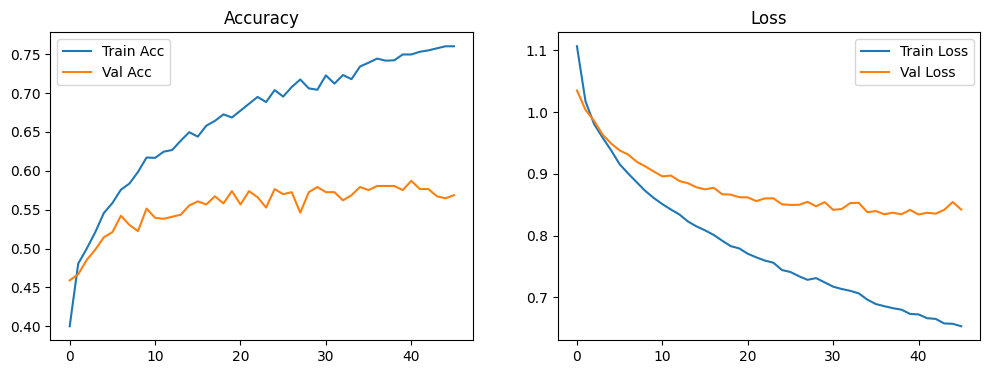

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

In [ ]:
predictions = model_1.predict(testX)
print(classification_report(testY.argmax(axis=1),
                          predictions.argmax(axis=1),
                          target_names=class_names))

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
              precision    recall  f1-score   support

         cat       0.57      0.57      0.57       252
         dog       0.49      0.43      0.46       253
       horse       0.68      0.76      0.72       253

    accuracy                           0.59       758
   macro avg       0.58      0.59      0.58       758
weighted avg       0.58      0.59      0.58       758



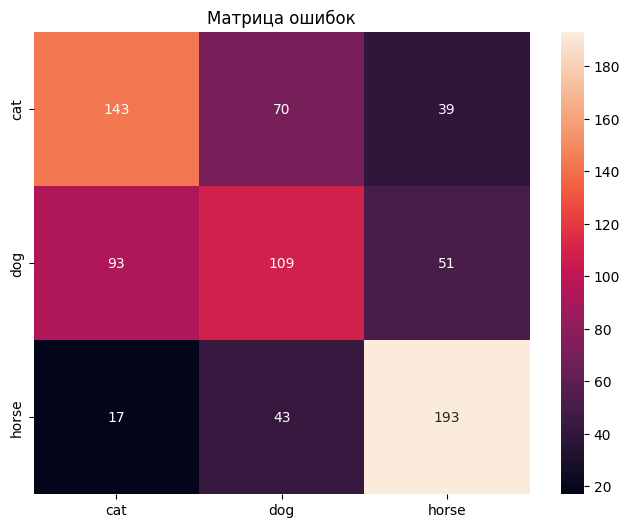

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(testY.argmax(axis=1), predictions.argmax(axis=1))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title('Матрица ошибок')
plt.show()

In [ ]:
# Сверточная модель
model_3 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3), kernel_regularizer=l2(0.01)),
    Conv2D(32, (3,3), activation='relu', kernel_regularizer=l2(0.01)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu', kernel_regularizer=l2(0.01)),
    Conv2D(64, (3,3), activation='relu', kernel_regularizer=l2(0.01)),
    MaxPooling2D((2,2)),

    Conv2D(96, (3,3), activation='relu', kernel_regularizer=l2(0.01)),
    Conv2D(96, (3,3), activation='relu', kernel_regularizer=l2(0.01)),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(3, activation='softmax')
])
model_3.summary()

BS = 128
EPOCHS = 50

model_3.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    ModelCheckpoint("/content/drive/MyDrive/model/10/model_cnn_minimal.keras", monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, min_delta=0.001),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=1e-8, verbose=1)
]

history_3 = model_3.fit(
    trainX, trainY,
    validation_data=(testX, testY),
    batch_size=BS,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 124, 124, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 58, 58, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 27, 27, 96)     │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 25, 25, 96)     │        83,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 13824)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,769,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,973,987 (7.53 MB)

 Trainable params: 1,973,987 (7.53 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 954ms/step - accuracy: 0.3440 - loss: 6.6201
Epoch 1: val_accuracy improved from None to 0.36412, saving model to /content/drive/MyDrive/model/10/model_cnn_minimal.keras

Epoch 1: finished saving model to /content/drive/MyDrive/model/10/model_cnn_minimal.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.3508 - loss: 6.4367 - val_accuracy: 0.3641 - val_loss: 6.0210 - learning_rate: 1.0000e-04
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.3959 - loss: 5.8518
Epoch 2: val_accuracy improved from 0.36412 to 0.43140, saving model to /content/drive/MyDrive/model/10/model_cnn_minimal.keras

Epoch 2: finished saving model to /content/drive/MyDrive/model/10/model_cnn_minimal.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 176ms/step - accuracy: 0.4155 - loss: 5.6920 - val_accuracy: 0.4314 - val_loss: 5.3361 - learning_rate: 1.0000e-04
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.4464 - loss: 5.1886
Epoch 3: val_accura

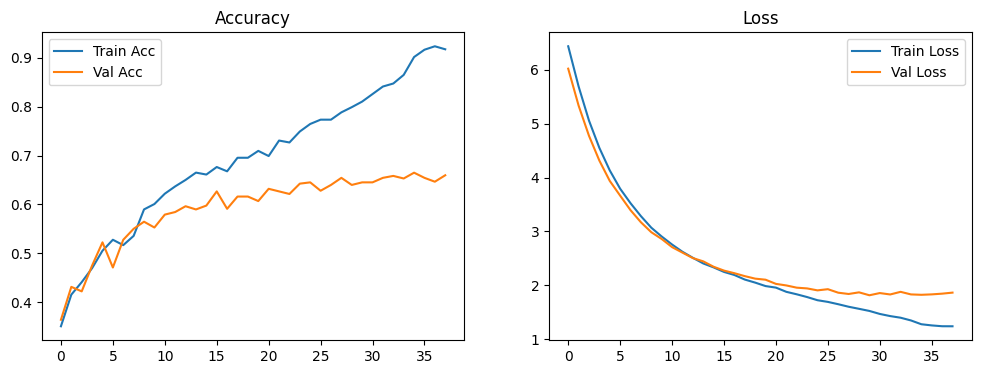

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_3.history['accuracy'], label='Train Acc')
plt.plot(history_3.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_3.history['loss'], label='Train Loss')
plt.plot(history_3.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

In [ ]:
predictions = model_3.predict(testX)
print(classification_report(testY.argmax(axis=1),
                          predictions.argmax(axis=1),
                          target_names=class_names))

24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step
              precision    recall  f1-score   support

         cat       0.61      0.66      0.64       252
         dog       0.55      0.49      0.51       253
       horse       0.77      0.79      0.78       253

    accuracy                           0.65       758
   macro avg       0.64      0.65      0.64       758
weighted avg       0.64      0.65      0.64       758



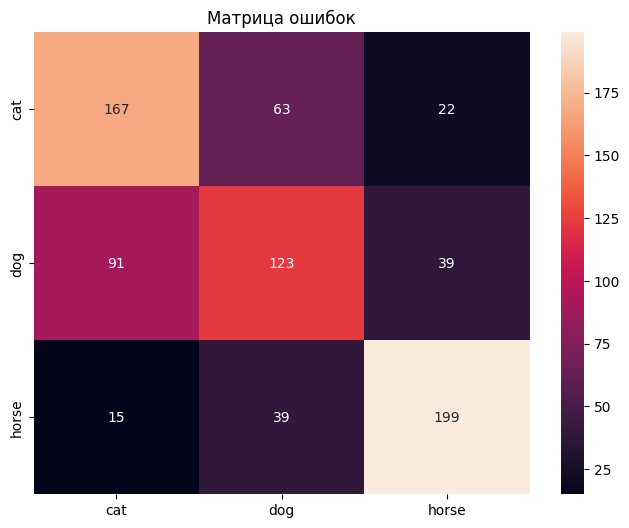

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(testY.argmax(axis=1), predictions.argmax(axis=1))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title('Матрица ошибок')
plt.show()

In [ ]:
# С предобученной моделью
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from imutils import paths
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 128
data_dir = DATASET_PATH
EPOCHS = 15
AUTOTUNE = tf.data.AUTOTUNE

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def my_custom_preprocessing(image, label):
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    return image, label

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)
train_ds = train_ds.map(my_custom_preprocessing, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(my_custom_preprocessing, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Замораживаем базовые слои предобученной модели
base_model.trainable = False

# Создаем модель с новыми верхними слоями
model_5 = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(len(lb.classes_), activation='softmax')
])

model_5.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print(model_5.summary())

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('/content/drive/MyDrive/model/10/mobile_best_model.keras', monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001)
]

history_5 = model_5.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1,
    shuffle=True
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Found 3129 files belonging to 3 classes.
Using 2504 files for training.
Found 3129 files belonging to 3 classes.
Using 625 files for validation.


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,203 (9.99 MB)

 Trainable params: 361,219 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

None
Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.5535 - loss: 0.9684 - val_accuracy: 0.9296 - val_loss: 0.4437 - learning_rate: 1.0000e-04
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 44s 141ms/step - accuracy: 0.8371 - loss: 0.4645 - val_accuracy: 0.9664 - val_loss: 0.2225 - learning_rate: 1.0000e-04
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 145ms/step - accuracy: 0.9097 - loss: 0.2844 - val_accuracy: 0.9792 - val_loss: 0.1340 - learning_rate: 1.0000e-04
Epoch 4/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 155ms/step - accuracy: 0.9421 - loss: 0.1966 - val_accuracy: 0.9808 - val_loss: 0.0974 - learning_rate: 1.0000e-04
Epoch 5/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 144ms/step - accuracy: 0.9617 - loss: 0.1412 - val_accuracy: 0.9840 - val_loss: 0.0812 - learning_rate: 1.0000e-04
Epoch 6/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - accuracy: 0.9629 - loss: 0.1193 - val_accuracy: 0.9824 - val_loss: 0.0707 - learning_rate: 1.0000e-04
Epoch 7/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - accur

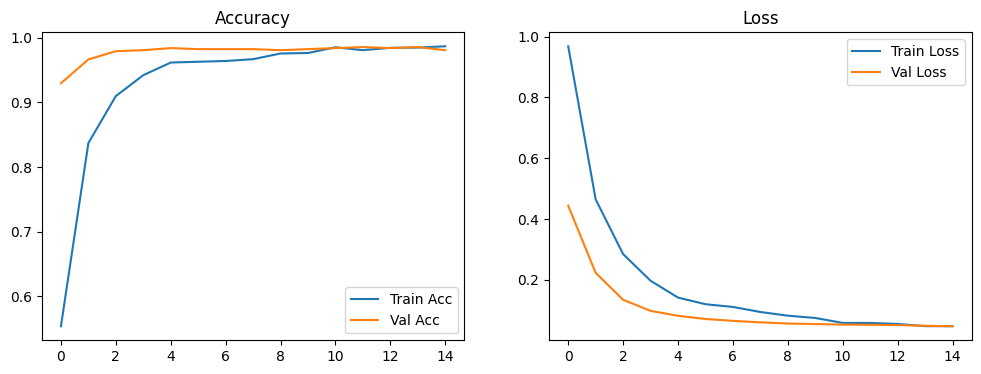

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_5.history['accuracy'], label='Train Acc')
plt.plot(history_5.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_5.history['loss'], label='Train Loss')
plt.plot(history_5.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

Обнаруженные классы: ['cat', 'dog', 'horse']
              precision    recall  f1-score   support

         cat       0.98      0.97      0.98       203
         dog       0.97      0.99      0.98       209
       horse       0.99      0.99      0.99       213

    accuracy                           0.98       625
   macro avg       0.98      0.98      0.98       625
weighted avg       0.98      0.98      0.98       625



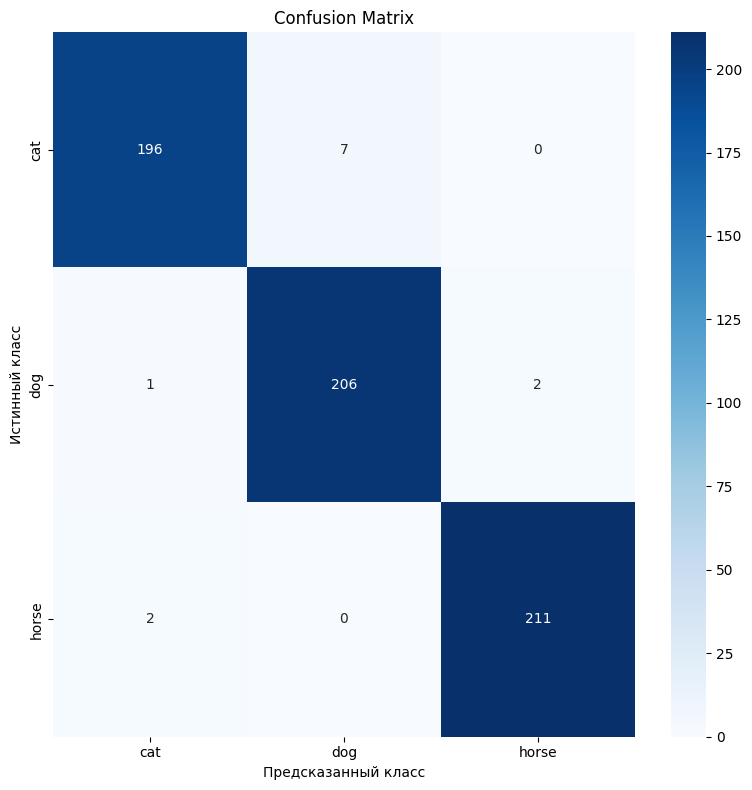


 Измерение времени инференса...
 Протестировано изображений: 625
 Среднее время: 1.61 мс/кадр
 Скорость: 621.57 FPS


In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model_5(images, training=False)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

class_names = sorted([d for d in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, d))])
print(f"Обнаруженные классы: {class_names}")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(max(8, len(class_names)*1.2), 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

print("\n Измерение времени инференса...")
num_batches = 20
times = []
count = 0

dummy = tf.zeros((1, IMG_HEIGHT, IMG_WIDTH, 3), dtype=tf.float32)
_ = model_5(dummy, training=False)

for images, _ in val_ds.take(num_batches):
    t0 = time.perf_counter()
    _ = model_5(images, training=False)
    times.append(time.perf_counter() - t0)
    count += images.shape[0]

total = sum(times)
ms_per_img = (total / count) * 1000
fps = 1000 / ms_per_img

print(f" Протестировано изображений: {count}")
print(f" Среднее время: {ms_per_img:.2f} мс/кадр")
print(f" Скорость: {fps:.2f} FPS")

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from imutils import paths
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
model_1 = tf.keras.models.load_model('/content/drive/MyDrive/model/10/dense_model.keras')
model_3 = tf.keras.models.load_model('/content/drive/MyDrive/model/10/model_cnn_minimal.keras')
model_5 = tf.keras.models.load_model('/content/drive/MyDrive/model/10/mobile_best_model.keras')

🔄 Подготовка общего тестового набора...
✅ testX (128x128, [0,1]): (758, 128, 128, 3), range=[0.00, 1.00]
✅ testX_224 (224x224, MobileNet): (758, 224, 224, 3), range=[-1.00, 1.00]

🔍 Оценка: Dense | input=128x128 | batch=64

🔍 Оценка: CNN | input=128x128 | batch=64

🔍 Оценка: MobileNetV2 | input=224x224 | batch=32

📊 СВОДНАЯ ТАБЛИЦА:
 model_name input_size  accuracy  precision  recall  f1_score  inference_time_ms
      Dense    128x128    0.5871     0.5794  0.5871    0.5818               0.35
        CNN    128x128    0.6649     0.6587  0.6649    0.6606               1.78
MobileNetV2    224x224    0.9749     0.9749  0.9749    0.9749               5.12
💾 Сохранено: /content/drive/MyDrive/model/10/model_comparison.csv


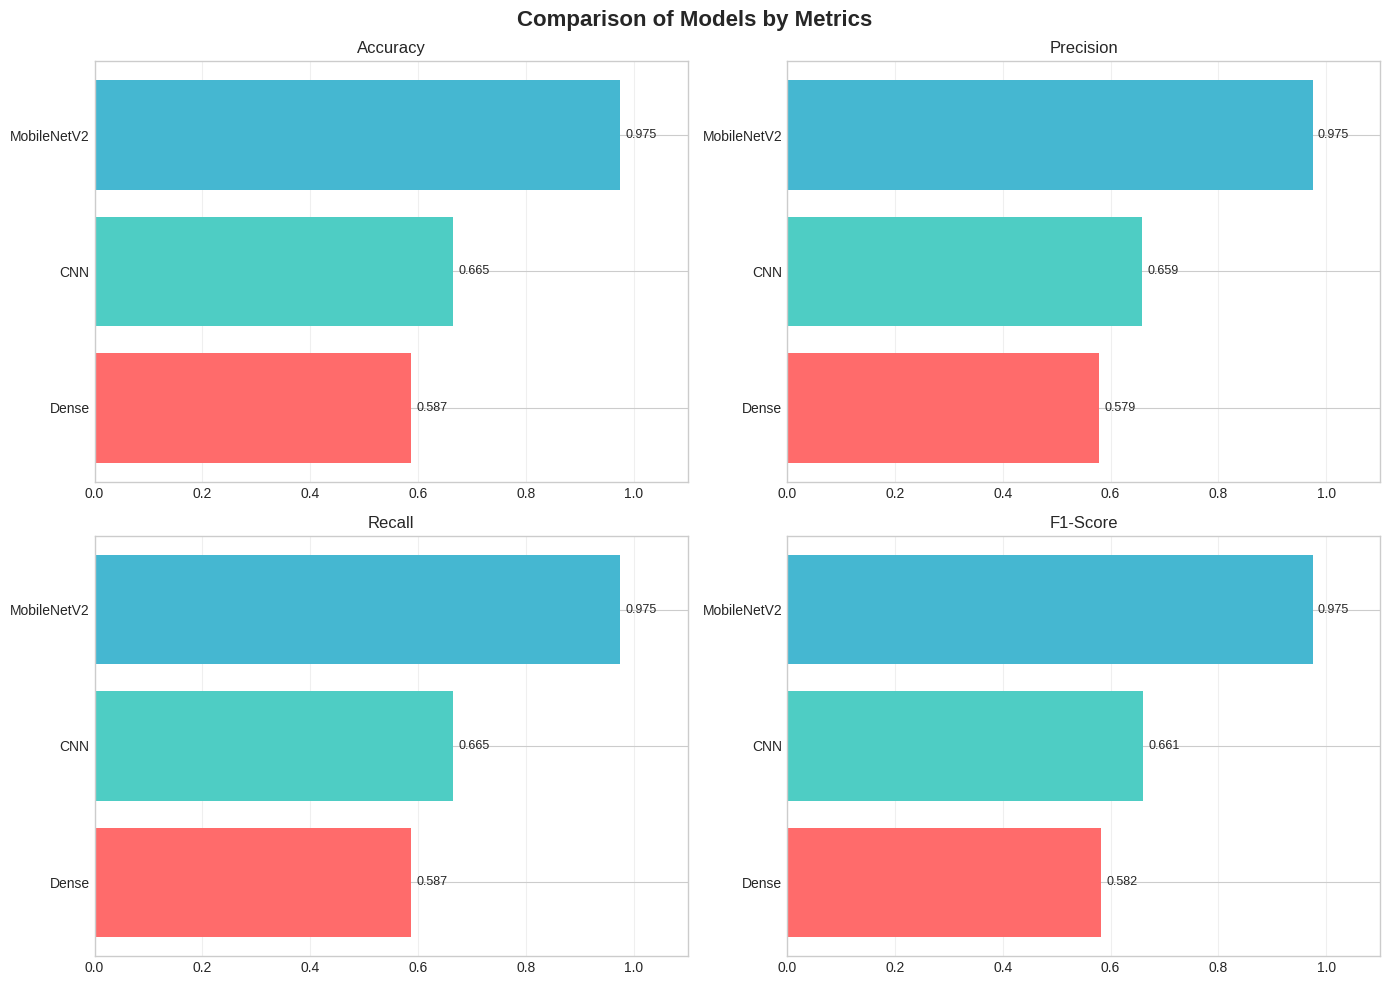

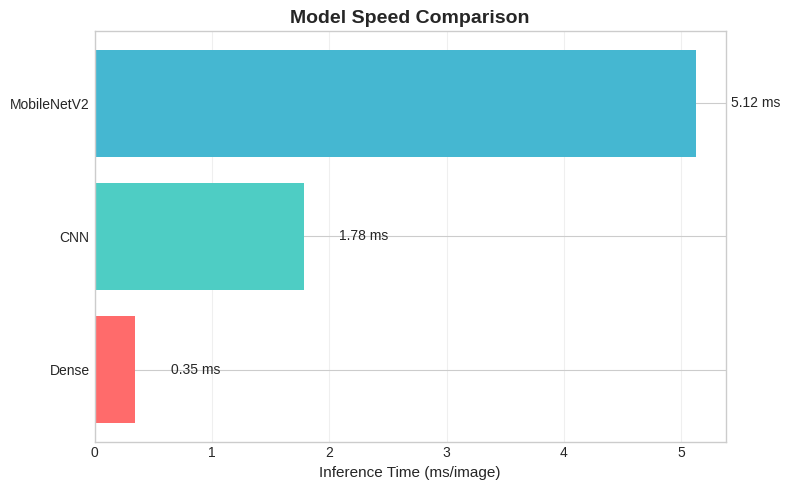

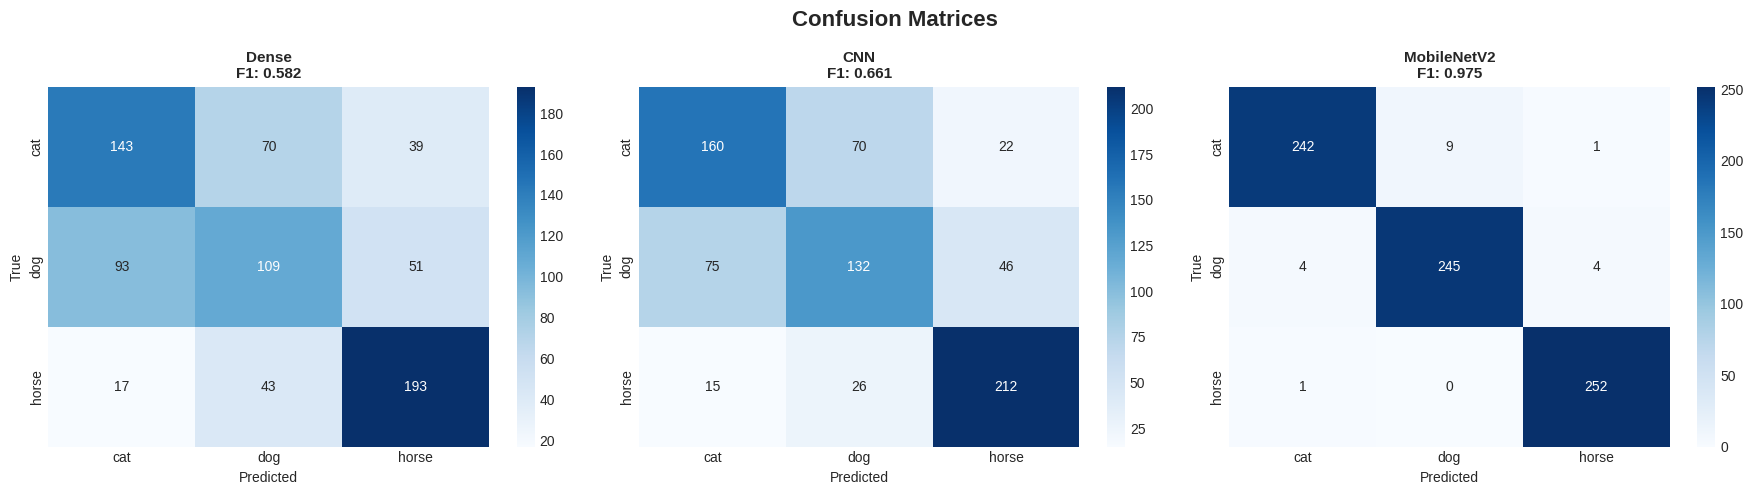


 BEST MODEL by F1-Score: MobileNetV2
   F1: 0.9749 | Acc: 0.9749 | Time: 5.12 ms
💾 Saved: /content/drive/MyDrive/model/10/best_model_final.keras


TypeError: Object of type ndarray is not JSON serializable

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)

# Настройка шрифтов для корректного отображения эмодзи (опционально)
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial Unicode MS', 'Liberation Sans']
plt.rcParams['axes.unicode_minus'] = False

print("🔄 Подготовка общего тестового набора...")

# ==========================================
# 1. Единый тестовый набор
# ==========================================
# testX уже в [0, 1] из предыдущих ячеек
# Для MobileNetV2: ресайз + правильная нормализация

# Опция 1: Вернуть к [0, 255] и применить preprocess_input (рекомендуется)
testX_224_raw = tf.image.resize(testX * 255, [224, 224]).numpy()  # *255 возвращает к исходному диапазону
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
testX_224 = mobilenet_preprocess(testX_224_raw)

print(f"✅ testX (128x128, [0,1]): {testX.shape}, range=[{testX.min():.2f}, {testX.max():.2f}]")
print(f"✅ testX_224 (224x224, MobileNet): {testX_224.shape}, range=[{testX_224.min():.2f}, {testX_224.max():.2f}]")

# ==========================================
# 2. Универсальная функция оценки
# ==========================================
def evaluate_model(model, X_test, y_test, model_name, input_size, batch_size=32):
    """Оценка модели с по-батчевой обработкой для экономии памяти"""
    print(f"\n🔍 Оценка: {model_name} | input={input_size} | batch={batch_size}")

    n = len(X_test)
    all_preds = []
    total_time = 0.0

    # Прогрев
    _ = model(X_test[:1], training=False)

    for i in range(0, n, batch_size):
        batch = X_test[i:i+batch_size]
        t0 = time.perf_counter()
        preds = model(batch, training=False)
        total_time += time.perf_counter() - t0
        all_preds.append(preds.numpy() if hasattr(preds, 'numpy') else preds)

    preds = np.concatenate(all_preds, axis=0)
    ms_per_img = (total_time / n) * 1000

    y_true = np.argmax(y_test, axis=1)
    y_pred = np.argmax(preds, axis=1)

    return {
        'model_name': model_name,
        'input_size': input_size,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'f1_score': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'inference_time_ms': ms_per_img,
        'y_true': y_true,
        'y_pred': y_pred
    }

# ==========================================
# 3. Оценка всех моделей
# ==========================================
results = []

# Model 1: Dense (вход [0, 1], 128x128)
results.append(evaluate_model(model_1, testX, testY, "Dense", "128x128", batch_size=64))

# Model 3: CNN (вход [0, 1], 128x128)
results.append(evaluate_model(model_3, testX, testY, "CNN", "128x128", batch_size=64))

# Model 5: MobileNetV2 (вход после preprocess_input, 224x224)
results.append(evaluate_model(model_5, testX_224, testY, "MobileNetV2", "224x224", batch_size=32))

# ==========================================
# 4. Сводная таблица
# ==========================================
df = pd.DataFrame(results)
df_display = df[['model_name', 'input_size', 'accuracy', 'precision', 'recall', 'f1_score', 'inference_time_ms']].copy()
df_display['inference_time_ms'] = df_display['inference_time_ms'].round(2)
df_display[['accuracy', 'precision', 'recall', 'f1_score']] = df_display[['accuracy', 'precision', 'recall', 'f1_score']].round(4)

print("\n📊 СВОДНАЯ ТАБЛИЦА:")
print(df_display.to_string(index=False))
df_display.to_csv('/content/drive/MyDrive/model/10/model_comparison.csv', index=False, encoding='utf-8-sig')
print(f"💾 Сохранено: /content/drive/MyDrive/model/10/model_comparison.csv")

# ==========================================
# 5. Визуализация метрик (без эмодзи для совместимости)
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparison of Models by Metrics', fontsize=16, fontweight='bold')

metrics = ['accuracy', 'precision', 'recall', 'f1_score']
titles = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for ax, metric, title in zip(axes.flat, metrics, titles):
    bars = ax.barh(df['model_name'], df[metric], color=colors)
    ax.set_xlim(0, 1.1)
    ax.grid(axis='x', alpha=0.3)
    ax.set_title(title, fontsize=12)
    for bar in bars:
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/model/10/metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Время инференса
plt.figure(figsize=(8, 5))
bars = plt.barh(df['model_name'], df['inference_time_ms'], color=colors)
plt.xlabel('Inference Time (ms/image)', fontsize=11)
plt.title('Model Speed Comparison', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
for bar in bars:
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.2f} ms', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/model/10/inference_time.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 6. Матрицы ошибок
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices', fontsize=16, fontweight='bold')

for res, ax in zip(results, axes):
    cm = confusion_matrix(res['y_true'], res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f"{res['model_name']}\nF1: {res['f1_score']:.3f}", fontweight='bold', fontsize=11)
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/model/10/confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 7. Выбор лучшей модели
# ==========================================
best_idx = df['f1_score'].idxmax()
best = df.iloc[best_idx]

print("\n" + "="*50)
print(f" BEST MODEL by F1-Score: {best['model_name']}")
print(f"   F1: {best['f1_score']:.4f} | Acc: {best['accuracy']:.4f} | Time: {best['inference_time_ms']:.2f} ms")
print("="*50)

# Сохранение
model_map = {"Dense": model_1, "CNN": model_3, "MobileNetV2": model_5}
best_model = model_map[best['model_name']]
save_path = '/content/drive/MyDrive/model/10/best_model_final.keras'
best_model.save(save_path)
print(f"💾 Saved: {save_path}")

# Экспорт метрик в JSON
import json
with open('/content/drive/MyDrive/model/10/best_model_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(best.to_dict(), f, indent=2)
print(f"📄 Metrics: /content/drive/MyDrive/model/10/best_model_metrics.json")

---

### **Раздел 2. Развертывание API**


1. Создать FastAPI приложение для обработки запросов с изображениями
2. Реализовать предобработку загружаемых изображений
3. Реализовать эндпоинт для классификации изображений
4. Добавить возврат предсказанного класса и вероятностей по всем классам
5. Создать файл requirements.txt с необходимыми зависимостями
6. Развернуть API на любом сервере с доступом из глобальной сети

#### **Инструкция по развёртыванию на Render.com**



**Шаги:**

1. **Репозиторий проекта:**
   - Создайте репозиторий на GitHub, содержащий файлы `main.py`, `requirements.txt`, `best_classification_model` и `scaler.pkl` (при наличии).

2. **Регистрация на Render.com:**
   - Зарегистрируйтесь на [Render.com](https://render.com/).

3. **Создание нового веб-сервиса:**
   - В панели управления Render.com создайте новый веб-сервис, связав его с вашим репозиторием.

4. **Настройка версии Python:**
   - В разделе **Environment Variables** (Переменные окружения) добавьте новую переменную:
     - **Key (Ключ):** `PYTHON_VERSION`
     - **Value (Значение):** `3.12.1`
   - Это позволит Render.com использовать указанную версию Python при сборке и запуске приложения.

5. **Настройка сервиса:**
   - Укажите команду запуска приложения: `uvicorn main:app --host 0.0.0.0 --port $PORT`.
   - Убедитесь, что в `requirements.txt` перечислены все необходимые зависимости.

6. **Развёртывание:**
   - Запустите процесс развёртывания и дождитесь его завершения.
   - После успешного развёртывания ваш API будет доступен по выделенному адресу.

#### **Инструкция по развёртыванию Hugging Face Spaces (если возникли пролемы с доступом к Render.com)**


**Шаги:**

1. **Регистрация:**
   - Зарегистрируйтесь на [huggingface.co](https://huggingface.co) (бесплатно, без карты).
   - Подтвердите e-mail.

2. **Создание нового Space:**
   - На главной странице нажмите на аватар → **New Space**.
   - Заполните поля:
     - **Space name:** `имя_проекта_backend`.
     - **License:** `mit` (или любая на ваш выбор).
     - **SDK:** выбрать **Docker** → **Blank**.
     - **Visibility:** `Public`.
     - **Hardware:** `CPU basic · 2 vCPU · 16 GB · FREE`.

3. **Push репозитория в Hugging Face:**
   - После создания Space Hugging Face даст адрес Git-репозитория вида `https://huggingface.co/spaces/ВАШ_USERNAME/california-regression`.
   - Добавьте его как удалённый репозиторий в ваш локальный проект:
   ```bash
   git remote add hf https://huggingface.co/spaces/ВАШ_USERNAME/ВАШ_РЕПОЗИТОРИЙ
   git push hf main
   ```
   - При push потребуется логин Hugging Face и **Access Token** (создаётся в Settings → Access Tokens с правом `write`).

4. **Автоматическая сборка:**
   - Hugging Face автоматически обнаружит `Dockerfile` и запустит сборку.
   - Процесс сборки занимает **5–10 минут** (установка TensorFlow — самая долгая часть).
   - Статус можно отслеживать на вкладке **Logs** в интерфейсе Space.

5. **Получение публичного URL:**
   - После успешного деплоя API доступен по адресу:
     ```
     https://ВАШ_USERNAME-ИМЯ-ПРОЕКТА.hf.space/predict
     ```
   - Этот URL работает 24/7 без усыпления, в отличие от бесплатных тарифов Render.com.

---

**Структура проекта для развёртывания на Hugging Face**

```
main.py
requirements.txt
Dockerfile
README.md
best_classification_model.h5
```

---

**Содержимое Dockerfile**


```dockerfile
# Используем официальный образ Python 3.12 (slim-версия для экономии места)
FROM python:3.12-slim

# Устанавливаем рабочую директорию внутри контейнера
WORKDIR /app

# Копируем файл зависимостей
COPY requirements.txt .

# Устанавливаем зависимости
RUN pip install --no-cache-dir --upgrade pip && \
    pip install --no-cache-dir -r requirements.txt

# Копируем все файлы проекта в контейнер
COPY . .

# Открываем порт 7860 (стандартный порт для Hugging Face Spaces)
EXPOSE 7860

# Команда запуска приложения
CMD ["uvicorn", "main:app", "--host", "0.0.0.0", "--port", "7860"]
```

---


#### **Ответ:**

**Ссылка на публичный API:** https://image-classification-project-nl0r.onrender.com/docs

---

### **Раздел 3. Создание интерфейса на Streamlit**



1. Разработать Streamlit-приложение со следующими функциями:
   - Возможность загрузки изображения пользователем
   - Возможность рисования изображения на холсте
   - Предобработка изображения перед отправкой на API
   - Отображение результатов классификации
   - Визуализация распределения вероятностей по классам
2. Развернуть Streamlit-приложение на платформе Streamlit Cloud

#### **Ответ:**

**Ссылка на публичный ФРОНТЭНД** https://image-classification-frontend-drhx.onrender.com/

---

### **Раздел 4. Документация и публикация проекта**


1. Создать GitHub-репозиторий со структурой:
   - Модели (сохраненная лучшая модель)
   - API (код и зависимости)
   - Интерфейс (код Streamlit-приложения)
   - Документация (README.md)
   - Требования (requirements.txt)
2. Добавить в README.md:
   - Описание проекта и используемого датасета
   - Описание сравниваемых моделей
   - Таблицу с результатами сравнения моделей
   - Визуализации результатов
   - Инструкции по локальному развертыванию
   - Ссылки на развернутый API и Streamlit-приложение
   - Примеры использования API
3. Предоставить ссылки на:
   - GitHub-репозиторий
   - Публичный API для отправки POST-запросов
   - Streamlit-интерфейс для взаимодействия с моделью

#### **Ответ:**

**Ссылка на GitHub-репозиторий:** https://github.com/Olya-Shulga/image_classification_project

---

#### **Пример**

- **GitHub-репозиторий:** https://github.com/Alexandre77777/dpo_classification.git

- **Публичный API для отправки POST-запросов:** https://dpo-classification.onrender.com/predict/

- **Streamlit-интерфейс для взаимодействия с моделью:** https://dpo-classification.streamlit.app/
